# Contexto

En este notebook realizaremos la logica y paso a paso para ajustar modelos de tipo CATBOOST a los datos,  
probar su desempeño, guardar los modelos ganadores y realizar submissions a la competencia de kaggle.

# Carga de paquetes

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectPercentile,
    chi2,
    mutual_info_classif,
)


# Scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
)
from xgboost import XGBClassifier

import optuna
from optuna.samplers import NSGAIISampler
from catboost import CatBoostClassifier

# XGBoost
import xgboost as xgb
from scipy.stats import randint, uniform


# LightGBM
import lightgbm as lgb

from scipy.stats import loguniform

from sklearn.ensemble import (
    RandomForestClassifier,
)  # Clasificador de bosque aleatorio.


from sklearn.preprocessing import (
    StandardScaler,
)  # Escalado de características para normalizar los datos.
from sklearn.preprocessing import (
    OneHotEncoder,
)  # Codificación one-hot para variables categóricas.

from imblearn.pipeline import Pipeline as imb_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA

import sklearn.metrics as skm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, ClassifierMixin, clone

import pickle  # Serialización y deserialización de objetos Python (guardar/cargar modelos).

# Carga de datos

In [2]:
filename = "catboost_optuna_model.ipynb"  # nombre del archivo actual
print(f"Current file name: {filename}\n")
print(f"Current absolute path: {os.getcwd()}\n")

# Especificamos la ruta del directorio actual y los directorios de datos y salida
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(os.path.dirname(ACTUAL_DIR))
DATA_DIR = os.path.join(BASE_DIR, "Data")
MODELS_DIR = os.path.join(DATA_DIR, "models")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")
SUB_DIR = os.path.join(DATA_DIR, "submissions")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {OUTPUT_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")
print(f"SUB_DIR: {SUB_DIR}")

Current file name: catboost_optuna_model.ipynb

Current absolute path: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\ML2 - Aprendizaje automatico 2\Competencia kaggle\competencia_ml2_icesi\Notebooks\Machine_learning

BASE_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\ML2 - Aprendizaje automatico 2\Competencia kaggle\competencia_ml2_icesi
DATA_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\ML2 - Aprendizaje automatico 2\Competencia kaggle\competencia_ml2_icesi\Data\output_data
MODELS_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\ML2 - Aprendizaje automatico 2\Competencia kaggle\competencia_ml2_icesi\Data\models
SUB_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\ML2 - Aprendizaje automatico 2\Competencia kaggle\competencia_ml2_icesi\Data\submissions


In [3]:
df = pd.read_parquet(os.path.join(OUTPUT_DIR, "df_train_clean.parquet"))
df_test = pd.read_parquet(os.path.join(OUTPUT_DIR, "df_test_clean.parquet"))

In [4]:
print(df.shape)
print()
df.info()

(3955, 41)

<class 'pandas.core.frame.DataFrame'>
Index: 3955 entries, 2987 to 898
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   genero                      3955 non-null   object 
 1   estado_civil                3955 non-null   object 
 2   multi_cancer                3955 non-null   int64  
 3   cesion                      3955 non-null   int64  
 4   riesgos                     3955 non-null   float64
 5   cancer_mama_familiar        3955 non-null   int64  
 6   cancer_otro_sitio           3955 non-null   int64  
 7   cancer_otro_sitio_familiar  3955 non-null   int64  
 8   cerebral_familiar           3955 non-null   int64  
 9   peso                        3955 non-null   float64
 10  talla                       3955 non-null   float64
 11  tsistolica                  3955 non-null   float64
 12  tdiastolica                 3955 non-null   float64
 13  target                  

In [5]:
X = df.drop(columns=["target"])
y = df["target"]

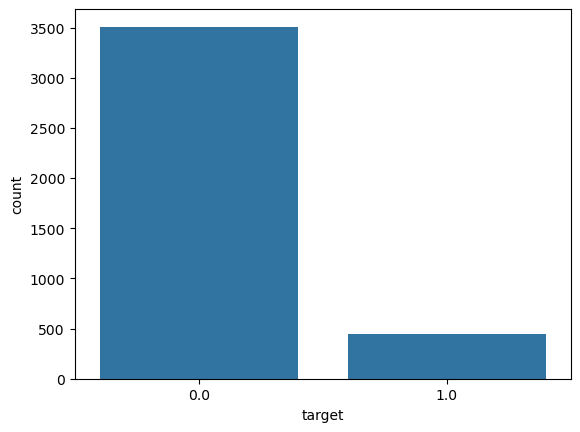

In [6]:
sns.countplot(x=y)
plt.show()

Es importante notar que estamos ante un caso de clasificación desbalanceada!

# Funciones utiles

In [7]:
def mejor_umbral(y_true, y_probs):
    """
    Calcula el mejor umbral para maximizar la métrica F1.
    """
    thresholds = np.linspace(0, 1, 1000)
    scores = [skm.f1_score(y_true, y_probs >= t) for t in thresholds]
    best_threshold = thresholds[np.argmax(scores)]

    return best_threshold

In [8]:
def evaluar_modelo_clasificacion(y_true, y_pred, y_proba=None, threshold=0.5):
    """
    Calcula y devuelve métricas para un caso de clasificación desbalanceado.

    Parámetros:
    -----------
    y_true : vector
        Valores reales o etiquetas verdaderas.
    y_pred : vector
        Valores predichos o etiquetas predichas.
    y_proba : vector, opcional
        Probabilidades predichas (para la clase positiva), útil para calcular AUC y PR-AUC.
    threshold : float, opcional
        Umbral de decisión utilizado para convertir probabilidades en etiquetas binarias.

    Retorna:
    --------
    dict
        Diccionario con las métricas calculadas: accuracy, precision, recall, f1,
        specificity, auc (si y_proba es proporcionado), pr_auc (si y_proba es proporcionado)
        y confusion_matrix.
    """
    # Métricas básicas
    accuracy = skm.accuracy_score(y_true, y_pred)
    precision = skm.precision_score(y_true, y_pred, zero_division=0)
    recall = skm.recall_score(y_true, y_pred, zero_division=0)
    f1 = skm.f1_score(y_true, y_pred, zero_division=0)
    kappa = skm.cohen_kappa_score(y_true, y_pred)

    # Matriz de confusión
    cm = skm.confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    # Especificidad (true negative rate)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Recopilar métricas en un diccionario
    metricas = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "kappa": kappa,
        "specificity": specificity,
        "confusion_matrix": cm,
    }

    # Añadir métricas basadas en probabilidades si están disponibles
    if y_proba is not None:
        try:
            # Área bajo la curva ROC
            metricas["auc"] = skm.roc_auc_score(y_true, y_proba)

            # Área bajo la curva PR
            precision_curve, recall_curve, _ = skm.precision_recall_curve(
                y_true, y_proba
            )
            pr_auc = skm.auc(recall_curve, precision_curve)
            metricas["pr_auc"] = pr_auc
        except:
            # En caso de que haya algún error (como una sola clase presente)
            metricas["auc"] = None
            metricas["pr_auc"] = None

    metricas["threshold"] = threshold

    return metricas

In [9]:
def plot_metrics_comparison(metrics_list, minority_class_pct=None, figsize=(14, 12)):
    """
    Visualiza métricas de clasificación para uno o más modelos.

    Parámetros:
    -----------
    metrics_list : list
        Lista de diccionarios con métricas de evaluación. Cada diccionario debe tener
        una clave 'name' que identifica el modelo y las métricas estándar (accuracy,
        precision, recall, f1, etc.)

    minority_class_pct : float, opcional
        Porcentaje de la clase minoritaria en los datos (entre 0 y 1).
        Si se proporciona, se dibuja una línea de referencia en los gráficos de barras.

    figsize : tuple, opcional
        Tamaño de la figura (ancho, alto)

    Retorna:
    --------
        Figura con los gráficos de métricas
    """

    # Verificar que hay métricas para visualizar
    if not metrics_list:
        print("No hay métricas para visualizar")
        return None

    # Asegurar que todos los diccionarios tienen una clave 'name'
    for i, metrics_dict in enumerate(metrics_list):
        if "name" not in metrics_dict:
            metrics_dict["name"] = f"Modelo {i+1}"

    # Métricas para visualizar
    main_metrics = ["accuracy", "precision", "recall", "f1", "kappa"]

    # Si hay métricas basadas en probabilidades, incluirlas
    if "auc" in metrics_list[0] and metrics_list[0]["auc"] is not None:
        main_metrics.extend(["auc", "pr_auc"])

    # Crear figura y subplots
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()

    # Colores para cada modelo
    colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_list)))

    # Para cada métrica, crear un gráfico de barras
    for i, metric in enumerate(main_metrics):
        if i < len(axes):  # Asegurarse de que hay suficientes subplots
            metric_values = [m.get(metric, 0) for m in metrics_list]
            model_names = [m["name"] for m in metrics_list]

            # Crear gráfico de barras
            bars = axes[i].bar(model_names, metric_values, color=colors)

            # Añadir valores encima de las barras
            for bar, val in zip(bars, metric_values):
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                )

            # Añadir línea para el porcentaje de clase minoritaria (baseline accuracy)
            if minority_class_pct is not None and metric == "accuracy":
                baseline = max(minority_class_pct, 1 - minority_class_pct)
                axes[i].axhline(y=baseline, color="r", linestyle="--", alpha=0.7)
                axes[i].text(
                    0,
                    baseline + 0.02,
                    f"Baseline: {baseline:.3f}",
                    color="r",
                    ha="left",
                    va="bottom",
                )

            # Configurar el gráfico
            axes[i].set_title(f"{metric.capitalize()}")
            axes[i].set_ylim([0, 1.1])
            axes[i].spines["top"].set_visible(False)
            axes[i].spines["right"].set_visible(False)

            # Rotar etiquetas si hay muchos modelos
            if len(model_names) > 3:
                axes[i].set_xticklabels(model_names, rotation=45, ha="right")

    # Si hay matriz de confusión, mostrarla para el último modelo
    if "confusion_matrix" in metrics_list[-1]:
        cm = metrics_list[-1]["confusion_matrix"]
        last_model_name = metrics_list[-1]["name"]

        # Mostrar matriz de confusión normalizada
        if i + 1 < len(axes):
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i + 1]
            )
            axes[i + 1].set_title(f"Matriz de Confusión\n{last_model_name}")
            axes[i + 1].set_xlabel("Predicción")
            axes[i + 1].set_ylabel("Real")
            axes[i + 1].set_xticklabels(["Neg", "Pos"])
            axes[i + 1].set_yticklabels(["Neg", "Pos"])

    # Eliminar subplots sobrantes
    for j in range(i + 2, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(
        "Comparación de Métricas de Clasificación - En test_data", fontsize=16, y=1.05
    )
    plt.subplots_adjust(top=0.9)

    return fig

# Modelado
A continuación, procedemos con la preparación y logica para ajustar/probar modelos Catboost a la data

In [10]:
# Dividimos el conjunto de datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=1, stratify=y
)

print(y_train.value_counts(True) * 100)
print()
print(y_test.value_counts(True) * 100)

target
0.0    88.704692
1.0    11.295308
Name: proportion, dtype: float64

target
0.0    88.636364
1.0    11.363636
Name: proportion, dtype: float64


## Pipelines y clases

Construimos pipelines para hacer mas reproducible los entrenamientos y evitar inconvenientes.

### Pipeline pre-procesamiento

In [11]:
# Definir variables categóricas y numéricas
categoricas = X.select_dtypes(include=["object"]).columns.tolist()
numericas = X.select_dtypes(exclude=["object"]).columns.tolist()

# Configuración para OneHotEncoder
config_onehot = {"handle_unknown": "ignore"}

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        # ("select_var", VarianceThreshold(0.2)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("dumm", OneHotEncoder(**config_onehot)),
        (
            "selector",
            SelectPercentile(mutual_info_classif, percentile=85),
        ),  # La chi2 solo tiene en cuenta relaciones lineales, la mutual_info_classif es más general.
    ]
)

# Pipeline para preprocesar los datos numericos y categoricos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numericas),
        ("cat", categorical_transformer, categoricas),
    ]
)

### Clase estimador

- Desarrollaremos una clase estimador (clasificador) para que internamente al ajustarse, halle el mejor umbral de decisión para las predicciones.  
- Para encontrar el mejor umbral, realizamos una logica de stratified kfold para determinar el mejor umbral   
evitando sesgarlo usando la misma data de entrenamiento.

In [22]:
class OptimalThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, base_model=None, scoring=skm.f1_score, cv_threshold=5, eval_set=None
    ):
        self.base_model = base_model
        self.scoring = scoring
        self.cv_threshold = cv_threshold  # número de folds para ajuste de threshold
        self.threshold_ = 0.5  # valor inicial
        self.eval_set = eval_set

    def fit(self, X, y):
        self.base_model_ = clone(self.base_model)  # para evitar conflictos

        # Ajuste del modelo completo para predicción final (fuera de CV)
        # Si eval_set está definido, se usa para el ajuste del modelo

        if self.eval_set is not None:
            self.base_model_.fit(X, y, eval_set=self.eval_set)
        else:
            self.base_model_.fit(X, y)

        self.classes_ = np.unique(y)

        # Validación cruzada para encontrar el mejor threshold
        skf = StratifiedKFold(n_splits=self.cv_threshold, shuffle=True, random_state=1)
        thresholds = []

        # Iteramos sobre los folds de validación cruzada
        for train_idx, val_idx in skf.split(X, y):
            X_train_cv, X_val_cv = X[train_idx], X[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

            model_cv = clone(self.base_model)

            # Ajuste del modelo en el fold actual
            # Si eval_set está definido, se usa para el ajuste del modelo
            if self.eval_set is not None:
                model_cv.fit(X_train_cv, y_train_cv, eval_set=self.eval_set)
            else:
                model_cv.fit(X_train_cv, y_train_cv)

            # Predecir probabilidades en el conjunto de validación
            y_probs_val = model_cv.predict_proba(X_val_cv)[:, 1]

            # Encontrar el mejor umbral para este fold
            best_thresh = mejor_umbral(y_val_cv, y_probs_val)
            thresholds.append(best_thresh)

        # Calcular el umbral óptimo como la media de los thresholds obtenidos
        self.threshold_ = np.mean(thresholds)

        return self

    def predict(self, X):
        probs = self.base_model_.predict_proba(X)[:, 1]
        return (probs >= self.threshold_).astype(int)

    def predict_proba(self, X):
        return self.base_model_.predict_proba(X)

    def score(self, X, y):
        try:
            score = self.scoring(y, self.predict(X))
            if np.isnan(score):
                return 0
            return score
        except:
            return 0

### Función-modelo

- Creamos funciones, las cuales integren los pasos de pre-procesamiento y la clase estimador.
- Las funciones varian dependiendo de si se utiliza PCA, o alguna estrategia de resampleo o under sampleo

In [13]:
def create_model(model, preprocessor):
    """
    Crea un pipeline de modelo con preprocesamiento y clasificador optimizado.
    """
    return Pipeline(
        [
            ("preprocessing", preprocessor),
            (
                "classifier",
                OptimalThresholdClassifier(
                    base_model=model, scoring=skm.f1_score, cv_threshold=3
                ),
            ),
        ]
    )

In [23]:
def create_model_with_strategies(
    model,
    preprocessor,
    n_components=0,
    smote=True,
    smote_proportion=0.5,
    under_proportion=0.5,
    eval_set=None,
):
    steps = [("preprocessing", preprocessor)]

    steps.append(
        (
            "under",
            RandomUnderSampler(sampling_strategy=under_proportion, random_state=100),
        )
    )

    if smote:
        steps.append(
            ("smote", SMOTE(sampling_strategy=smote_proportion, random_state=100))
        )

    if n_components > 0:
        steps.append(("pca", PCA(n_components=n_components)))

    steps.append(
        (
            "classifier",
            OptimalThresholdClassifier(
                base_model=model,
                scoring=skm.f1_score,
                cv_threshold=5,
                eval_set=eval_set,
            ),
        )
    )

    return imb_pipeline(steps)

## Modelos base

Ajustamos un modelo base sobre el cual iteraremos para encontrar los mejores hiperparametros

In [35]:
# Ajustar el modelo base a los datos de entrenamiento

catboost_base_model = create_model(
    CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=7,
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=1,
        verbose=10,
    ),
    preprocessor,
)

catboost_base_model.fit(X_train, y_train)

threshold_optimo = catboost_base_model.named_steps["classifier"].threshold_
print("Threshold óptimo calculado:", threshold_optimo)

params = catboost_base_model.named_steps["classifier"].base_model_.get_params()
print("\nParámetros del modelo:\n", params)

# Predecimos en el conjunto de prueba
y_pred = catboost_base_model.predict(X_test)
y_proba = catboost_base_model.predict_proba(X_test)[:, 1]

# Evaluar el modelo
metrics_catboost = evaluar_modelo_clasificacion(
    y_test, y_pred, y_proba=y_proba, threshold=threshold_optimo
)
print(f"`\nMétricas del modelo catboost:\n", metrics_catboost)

0:	learn: 0.5308848	total: 3.6ms	remaining: 3.59s
10:	learn: 0.5250432	total: 38ms	remaining: 3.42s
20:	learn: 0.5292096	total: 75.6ms	remaining: 3.53s
30:	learn: 0.5360825	total: 118ms	remaining: 3.69s
40:	learn: 0.5420240	total: 160ms	remaining: 3.73s
50:	learn: 0.5627119	total: 204ms	remaining: 3.8s
60:	learn: 0.5791246	total: 251ms	remaining: 3.86s
70:	learn: 0.5919732	total: 297ms	remaining: 3.88s
80:	learn: 0.6239737	total: 338ms	remaining: 3.83s
90:	learn: 0.6315789	total: 373ms	remaining: 3.73s
100:	learn: 0.6503268	total: 408ms	remaining: 3.63s
110:	learn: 0.6634304	total: 449ms	remaining: 3.59s
120:	learn: 0.6805778	total: 494ms	remaining: 3.59s
130:	learn: 0.6974522	total: 536ms	remaining: 3.55s
140:	learn: 0.7077409	total: 578ms	remaining: 3.52s
150:	learn: 0.7181102	total: 622ms	remaining: 3.5s
160:	learn: 0.7379845	total: 664ms	remaining: 3.46s
170:	learn: 0.7526882	total: 704ms	remaining: 3.41s
180:	learn: 0.7752640	total: 744ms	remaining: 3.37s
190:	learn: 0.7910448	tot

In [24]:
########
### Construimos un  modelo, con pasos adicionales ajustables, como SMOTE y PCA
#######

preprocessor.fit(X_train, y_train)
X_test_trans = preprocessor.transform(X_test)

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    early_stopping_rounds=200,
    loss_function="Logloss",
    random_seed=1,
    verbose=10,
    eval_metric="F1",
)

# Entrenamos el modelo
catboost_model_under = create_model_with_strategies(
    model,
    preprocessor,
    n_components=0,
    smote=True,
    smote_proportion=0.5,
    under_proportion=0.2,
    eval_set=(
        X_test_trans,
        y_test,
    ),
)

catboost_model_under.fit(X_train, y_train)

threshold_optimo = catboost_model_under.named_steps["classifier"].threshold_
print("Threshold óptimo calculado:", threshold_optimo)
params_2 = catboost_model_under.named_steps["classifier"].base_model_.get_params()
print("\nParámetros del modelo:\n", params_2)

# Predecimos en el conjunto de prueba
y_pred_2 = catboost_model_under.predict(X_test)
y_proba_2 = catboost_model_under.predict_proba(X_test)[:, 1]

# Evaluar el modelo
metrics_catboost_2 = evaluar_modelo_clasificacion(
    y_test, y_pred_2, y_proba=y_proba_2, threshold=threshold_optimo
)
print(f"\nMétricas del modelo catboost_model #2:")
print(metrics_catboost_2)

0:	learn: 0.7164015	test: 0.4130435	best: 0.4130435 (0)	total: 14.1ms	remaining: 21.2s
10:	learn: 0.8184224	test: 0.4516129	best: 0.4516129 (10)	total: 150ms	remaining: 20.3s
20:	learn: 0.8530351	test: 0.4186047	best: 0.4516129 (10)	total: 278ms	remaining: 19.6s
30:	learn: 0.8699789	test: 0.4634146	best: 0.4634146 (30)	total: 413ms	remaining: 19.6s
40:	learn: 0.8873539	test: 0.4000000	best: 0.4634146 (30)	total: 567ms	remaining: 20.2s
50:	learn: 0.8997347	test: 0.4225352	best: 0.4634146 (30)	total: 724ms	remaining: 20.6s
60:	learn: 0.9054198	test: 0.4285714	best: 0.4634146 (30)	total: 874ms	remaining: 20.6s
70:	learn: 0.9171504	test: 0.4166667	best: 0.4634146 (30)	total: 1.01s	remaining: 20.3s
80:	learn: 0.9277487	test: 0.4411765	best: 0.4634146 (30)	total: 1.14s	remaining: 19.9s
90:	learn: 0.9354167	test: 0.4285714	best: 0.4634146 (30)	total: 1.26s	remaining: 19.5s
100:	learn: 0.9414811	test: 0.4411765	best: 0.4634146 (30)	total: 1.39s	remaining: 19.2s
110:	learn: 0.9484004	test: 0.41

## Tuneo de hiperparametros

En este punto probaremos diferentes hiperparametros y criterios para obtener los mejores resultados posibles con la data y el modelo utilizado

### Con estrategias

In [26]:
# Hiperparámetros de CatBoost con Optuna

# División para validación (puedes omitir si haces CV sobre todo X_train)
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=1
)


def objective(trial):
    # Sugerir hiperparámetros de CatBoost
    params = {
        "iterations": trial.suggest_int("iterations", 500, 5000, step=50),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.2, step=0.0005),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 4, 13, step=0.5),
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 2, 6, step=0.2
        ),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 3, 9, step=0.1),
        "random_strength": trial.suggest_float("random_strength", 1, 10, step=0.2),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 100, step=5),
        "max_bin": trial.suggest_int("max_bin", 100, 450, step=10),
        "grow_policy": trial.suggest_categorical(
            "grow_policy", ["SymmetricTree", "Lossguide"]
        ),
    }

    strategies = {
        "under_proportion": trial.suggest_float(
            "under_proportion", 0.15, 0.25, step=0.01
        ),
        "smote_ratio": trial.suggest_float("smote_ratio", 0.3, 0.6, step=0.01),
    }

    # pre-process validation data
    preprocessor.fit(X_tune, y_tune)
    X_val_trans = preprocessor.transform(X_val)

    # Modelo base CatBoost (modo silencioso para evitar spam)
    cat_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        early_stopping_rounds=250,
        random_seed=1,
        verbose=0,
        thread_count=-1,
        **params,
    )

    # Pipeline con preprocesamiento y sampleo (ajusta según tu función)
    pipeline = create_model_with_strategies(
        cat_model,
        preprocessor,
        n_components=0,
        smote=True,
        smote_proportion=strategies["smote_ratio"],
        under_proportion=strategies["under_proportion"],
        eval_set=(X_val_trans, y_val),
    )

    # Split simple, tipo holdout para validación
    pipeline.fit(X_tune, y_tune)

    y_tune_pred = pipeline.predict(X_tune)
    y_val_pred = pipeline.predict(X_val)

    f1_train = skm.f1_score(y_tune, y_tune_pred)
    f1_test = skm.f1_score(y_val, y_val_pred)
    gen_ratio = f1_test / (f1_train + 1e-6)

    return gen_ratio, -f1_test


# Crear estudio multiobjetivo
study = optuna.create_study(
    directions=["maximize", "minimize"], sampler=NSGAIISampler(seed=42)
)
study.optimize(objective, n_trials=300, n_jobs=-1)

[I 2025-05-27 07:38:03,870] A new study created in memory with name: no-name-2a71db03-5e0f-4a70-bb7b-36b463719f7f
c:\Users\jhona\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1173: RuntimeWarning: invalid value encountered in divide
  * (last_sum / last_over_new_count - new_sum) ** 2
[I 2025-05-27 07:41:17,219] Trial 7 finished with values: [0.7682704003661623, -0.49] and parameters: {'iterations': 2600, 'depth': 3, 'learning_rate': 0.13, 'l2_leaf_reg': 12.5, 'bagging_temperature': 5.2, 'scale_pos_weight': 3.2, 'random_strength': 8.4, 'min_data_in_leaf': 40, 'max_bin': 380, 'grow_policy': 'Lossguide', 'under_proportion': 0.21, 'smote_ratio': 0.36}.
[I 2025-05-27 07:41:36,606] Trial 4 finished with values: [0.8099469015119198, -0.526829268292683] and parameters: {'iterations': 3150, 'depth': 4, 'learning_rate': 0.139, 'l2_leaf_reg': 10.0, 'bagging_temperature': 6.0, 'scale_pos_weight': 3.7, 'random_strength': 4.800000000000001, 'min_data_in_leaf': 25, 'max_bin': 320, 'grow_policy

In [27]:
# Resultados
pareto_front = study.best_trials
for i, trial in enumerate(pareto_front):
    print(f"\nTrial {i}:")
    print("  gen_ratio:", trial.values[0])
    print("  -F1 test:", trial.values[1])
    print("  Params:", trial.params)


Trial 0:
  gen_ratio: 0.9340643772919719
  -F1 test: -0.5604395604395604
  Params: {'iterations': 3350, 'depth': 3, 'learning_rate': 0.13, 'l2_leaf_reg': 8.5, 'bagging_temperature': 5.2, 'scale_pos_weight': 3.2, 'random_strength': 5.6000000000000005, 'min_data_in_leaf': 75, 'max_bin': 350, 'grow_policy': 'Lossguide', 'under_proportion': 0.21, 'smote_ratio': 0.4}

Trial 1:
  gen_ratio: 0.9497069183280726
  -F1 test: -0.48412698412698413
  Params: {'iterations': 4300, 'depth': 5, 'learning_rate': 0.0445, 'l2_leaf_reg': 11.0, 'bagging_temperature': 2.6, 'scale_pos_weight': 3.0, 'random_strength': 6.4, 'min_data_in_leaf': 25, 'max_bin': 310, 'grow_policy': 'SymmetricTree', 'under_proportion': 0.25, 'smote_ratio': 0.38}

Trial 2:
  gen_ratio: 0.9728065391822005
  -F1 test: -0.4268292682926829
  Params: {'iterations': 750, 'depth': 3, 'learning_rate': 0.012, 'l2_leaf_reg': 10.5, 'bagging_temperature': 4.800000000000001, 'scale_pos_weight': 7.7, 'random_strength': 6.6000000000000005, 'min_da

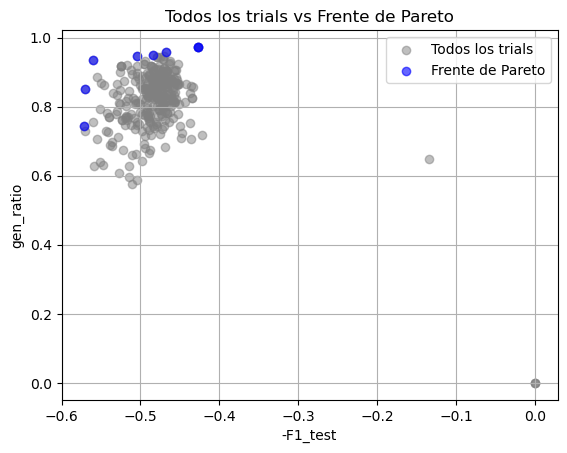

In [28]:
# Graficar el frente de pareto

pareto_front = study.best_trials
f1s = [t.values[1] for t in pareto_front]
gen_ratio = [t.values[0] for t in pareto_front]

trials = study.trials
f1s_all = [t.values[1] for t in trials]
gen_ratio_all = [t.values[0] for t in trials]

plt.scatter(f1s_all, gen_ratio_all, c="gray", alpha=0.5, label="Todos los trials")
plt.scatter(f1s, gen_ratio, c="blue", alpha=0.6, label="Frente de Pareto")
plt.xlabel("-F1_test")
plt.ylabel("gen_ratio")
plt.title("Todos los trials vs Frente de Pareto")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# optuna.visualization.plot_optimization_history(
#     study, target=lambda t: t.values[0]
# )  # F1

# optuna.visualization.plot_optimization_history(
#     study, target=lambda t: t.values[1]
# )  # Diferencia

In [29]:
# Graficas para validar los resultados de optuna

imp = optuna.visualization.plot_param_importances(study)

slice1 = optuna.visualization.plot_slice(
    study, target=lambda t: t.values[0], target_name="Gen_ratio"
)

slice2 = optuna.visualization.plot_slice(
    study, target=lambda t: t.values[1], target_name="F1 Test Score"
)

imp.show()
slice1.show()
slice2.show()

par1 = optuna.visualization.plot_parallel_coordinate(
    study, target=lambda t: t.values[0], target_name="Gen_ratio"
)

par2 = optuna.visualization.plot_parallel_coordinate(
    study, target=lambda t: t.values[1], target_name="F1 Test Score"
)

par1.show()
par2.show()

#### Entrenar mejor modelo

In [32]:
# predicion con el mejor modelo encontrado
best_trial = study.best_trials[0]
catboost_tune_params = best_trial.params

# Preprocesar los datos de entrenamiento y validación
preprocessor.fit(X_train, y_train)
X_test_trans = preprocessor.transform(X_test)

# Crear el modelo CatBoost con los mejores hiperparámetros encontrados
catboost_tune_model = CatBoostClassifier(
    iterations=catboost_tune_params["iterations"],
    depth=catboost_tune_params["depth"],
    learning_rate=catboost_tune_params["learning_rate"],
    l2_leaf_reg=catboost_tune_params["l2_leaf_reg"],
    bagging_temperature=catboost_tune_params["bagging_temperature"],
    scale_pos_weight=catboost_tune_params["scale_pos_weight"],
    random_strength=catboost_tune_params["random_strength"],
    min_data_in_leaf=catboost_tune_params["min_data_in_leaf"],
    max_bin=catboost_tune_params["max_bin"],
    grow_policy=catboost_tune_params["grow_policy"],
    loss_function="Logloss",
    eval_metric="F1",
    early_stopping_rounds=250,
    random_seed=100,
    verbose=10,
    thread_count=-1,
)

# Pipeline con preprocesamiento y sampleo
catboost_tune_pipeline = create_model_with_strategies(
    catboost_tune_model,
    preprocessor,
    n_components=0,
    smote=True,
    smote_proportion=catboost_tune_params["smote_ratio"],
    under_proportion=catboost_tune_params["under_proportion"],
    eval_set=(X_test_trans, y_test),
)

catboost_tune_pipeline.fit(X_train, y_train)

y_pred_cat_tune1 = catboost_tune_pipeline.predict(X_test)
y_proba_cat_tune1 = catboost_tune_pipeline.predict_proba(X_test)[:, 1]

metrics_best_cat_tune1 = evaluar_modelo_clasificacion(
    y_test, y_pred_cat_tune1, y_proba=y_proba_cat_tune1
)

0:	learn: 0.7673895	test: 0.5849695	best: 0.5849695 (0)	total: 3.32ms	remaining: 11.1s
10:	learn: 0.8378273	test: 0.6187845	best: 0.6343612 (7)	total: 30.4ms	remaining: 9.24s
20:	learn: 0.8461538	test: 0.6202965	best: 0.6343612 (7)	total: 59.1ms	remaining: 9.37s
30:	learn: 0.8496136	test: 0.6185333	best: 0.6343612 (7)	total: 84.5ms	remaining: 9.04s
40:	learn: 0.8526027	test: 0.6238532	best: 0.6343612 (7)	total: 110ms	remaining: 8.88s
50:	learn: 0.8566185	test: 0.6274510	best: 0.6343612 (7)	total: 135ms	remaining: 8.76s
60:	learn: 0.8660041	test: 0.6312014	best: 0.6343612 (7)	total: 162ms	remaining: 8.71s
70:	learn: 0.8721201	test: 0.6313194	best: 0.6369119 (63)	total: 184ms	remaining: 8.51s
80:	learn: 0.8821024	test: 0.6472819	best: 0.6472819 (80)	total: 209ms	remaining: 8.43s
90:	learn: 0.8960724	test: 0.6021505	best: 0.6472819 (80)	total: 237ms	remaining: 8.47s
100:	learn: 0.9002392	test: 0.6211513	best: 0.6472819 (80)	total: 263ms	remaining: 8.45s
110:	learn: 0.9056237	test: 0.63172

In [33]:
metrics_best_cat_tune1

{'accuracy': 0.8131313131313131,
 'precision': 0.3333333333333333,
 'recall': 0.6444444444444445,
 'f1': 0.4393939393939394,
 'kappa': 0.3406237343053867,
 'specificity': 0.8347578347578347,
 'confusion_matrix': array([[293,  58],
        [ 16,  29]], dtype=int64),
 'auc': 0.8346312124089902,
 'pr_auc': 0.5047076838720569,
 'threshold': 0.5}

## Comparación y selección

Comparamos el resultado de diferentes modelos para escoger aquellos que usaremos para aplicar submissions

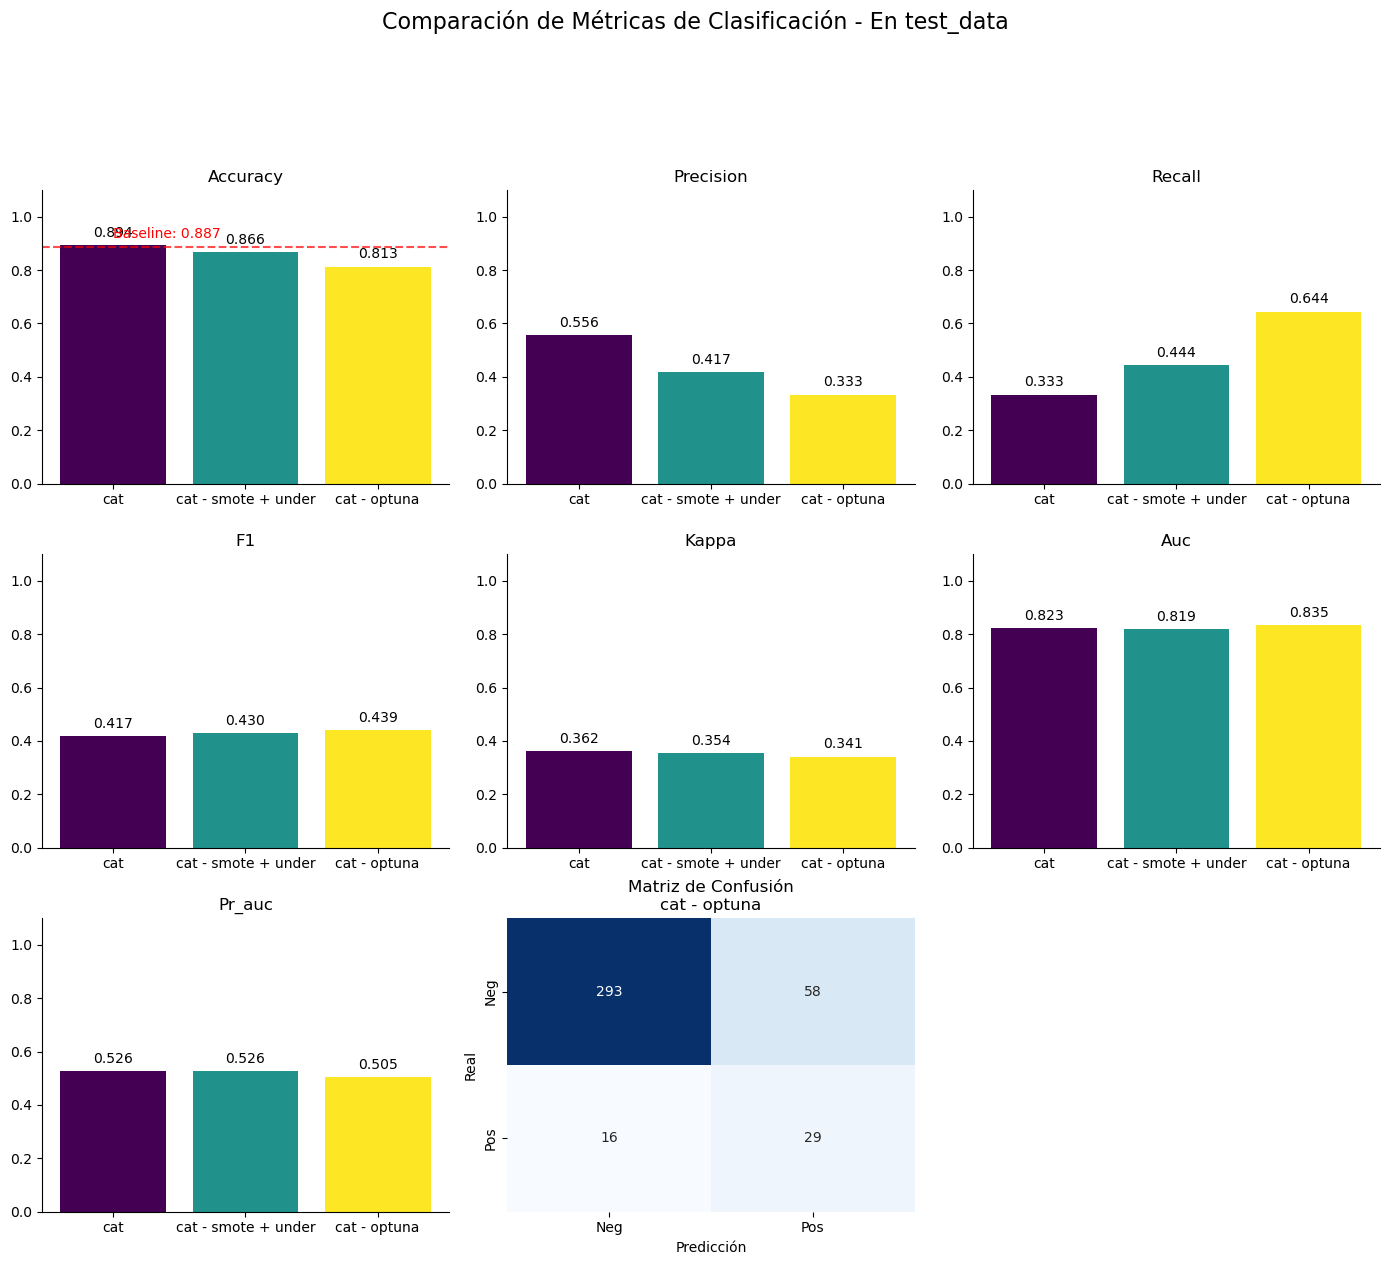

In [36]:
metrics_catboost["name"] = "cat"
metrics_catboost_2["name"] = "cat - smote + under"
metrics_best_cat_tune1["name"] = "cat - optuna"

fig = plot_metrics_comparison(
    [metrics_catboost, metrics_catboost_2, metrics_best_cat_tune1],
    minority_class_pct=y_train.value_counts(normalize=True)[1],
    figsize=(14, 12),
)

# Guardar mejor modelo

In [ ]:
# t = params_opt_xgb_2

In [37]:
# El mejor modelo lo re-entrenamos con toda la data disponible,
# usando el threshold óptimo y los parametros óptimos

w_strategies = True

if w_strategies:

    model_params = catboost_tune_params.copy()
    del model_params["smote_ratio"]
    del model_params["under_proportion"]

    catboost_final_model = create_model_with_strategies(
        CatBoostClassifier(
            **model_params,
            loss_function="Logloss",
            eval_metric="F1",
            early_stopping_rounds=100,
            random_seed=100,
            verbose=10,
            thread_count=-1,
        ),
        preprocessor,
        n_components=0,
        smote=True,
        smote_proportion=catboost_tune_params["smote_ratio"],
        under_proportion=catboost_tune_params["under_proportion"],
    )

else:
    catboost_final_model = create_model(
        CatBoostClassifier(**params),
        preprocessor,
    )

catboost_final_model.fit(X, y)

0:	learn: 0.7992416	total: 2.77ms	remaining: 9.27s
10:	learn: 0.8384972	total: 30.5ms	remaining: 9.25s
20:	learn: 0.8458100	total: 54.3ms	remaining: 8.61s
30:	learn: 0.8486668	total: 79.4ms	remaining: 8.5s
40:	learn: 0.8550404	total: 103ms	remaining: 8.31s
50:	learn: 0.8582990	total: 131ms	remaining: 8.45s
60:	learn: 0.8614192	total: 169ms	remaining: 9.09s
70:	learn: 0.8676291	total: 203ms	remaining: 9.39s
80:	learn: 0.8789115	total: 234ms	remaining: 9.44s
90:	learn: 0.8854718	total: 260ms	remaining: 9.32s
100:	learn: 0.8938678	total: 284ms	remaining: 9.14s
110:	learn: 0.8963225	total: 306ms	remaining: 8.93s
120:	learn: 0.9039219	total: 327ms	remaining: 8.73s
130:	learn: 0.9047671	total: 347ms	remaining: 8.53s
140:	learn: 0.9117175	total: 369ms	remaining: 8.39s
150:	learn: 0.9141855	total: 389ms	remaining: 8.23s
160:	learn: 0.9182629	total: 410ms	remaining: 8.12s
170:	learn: 0.9203669	total: 443ms	remaining: 8.24s
180:	learn: 0.9234821	total: 473ms	remaining: 8.28s
190:	learn: 0.925706

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['multi_cancer', 'cesion',
                                                   'riesgos',
                                                   'cancer_mama_familiar',
                                                   'cancer_otro_sitio',
                                                   'cancer_otro_sitio_familiar',
                                                   'cerebral_familiar', 'peso',
                                                   'talla', 'tsistolica',
                                                   'tdiastolica', 'mes_6',
                                                   'mes_5', 'mes_4', 'mes_3',
                                                   'me...
                                                   'atencion_nutricion',
                                                   'grupo_edad',
                                                   'codigo_sede_categ',
                                                   'peso_cat', 'talla_cat',
                                                   'tsistolica_cat',
                                                   'tdiastolica_cat',
                                                   'imc'])])),
                ('under',
                 RandomUnderSampler(random_state=100, sampling_strategy=0.21)),
                ('smote', SMOTE(random_state=100, sampling_strategy=0.4)),
                ('classifier',
                 OptimalThresholdClassifier(base_model=<catboost.core.CatBoostClassifier object at 0x0000017EBDAAB830>))])

In [38]:
# Guardar como .pickle el modelo con mejor f1-score

time = pd.Timestamp.now().strftime("%Y_%m_%d__%H")
name = f"catboost_final_model{time}.pickle"

with open(os.path.join(MODELS_DIR, name), "wb") as f:
    pickle.dump(catboost_final_model, f)

# Submission

In [39]:
with open(os.path.join(MODELS_DIR, f"catboost_final_model{time}.pickle"), "rb") as f:

    catboost_final_model = pickle.load(f)

In [40]:
# Utilizamos el mejor modelo para predecir en el conjunto df_test
y_pred_submission = catboost_final_model.predict(df_test)
submission = pd.DataFrame(
    {
        "ID": df_test.index,
        "Target": y_pred_submission,
    }
)
print(submission.sample(5))

# Guardar resultados como .csv
submission.to_csv(
    os.path.join(SUB_DIR, f"submission_catboost_optuna_{time}.csv"),
    index=False,
    sep=",",
)

        ID  Target
195   2167       0
707   6541       0
1330  5285       0
86    6333       0
1210  5474       0


# SANDBOX

In [42]:
# Carga los archivos CSV
df1 = pd.read_csv(
    os.path.join(SUB_DIR, "submission_catboost_optuna_2025_05_27__09.csv")
)
df3 = pd.read_csv(os.path.join(SUB_DIR, "submission_xgboost_2025_05_21__17.csv"))

# Une los dataframes por la columna 'ID'
merged = df1.merge(df3, on="ID", suffixes=("_13", "_17"))

# Compara los valores de Target
merged["Target_match"] = merged["Target_13"] == merged["Target_17"]
match_percentage = merged["Target_match"].mean() * 100
print(f"Porcentaje de coincidencia en Target: {match_percentage:.2f}%")

Porcentaje de coincidencia en Target: 92.57%


## Conclusiones